# Estudo prático sobre Redes Neurais Recorrentes

## Objetivo
Geração de texto autoregressivo

## Tipo de tokenização
Subword-level (BPE)

## Dataset
Wikipedia (no-pic-pt)

## Idioma
Português

## Tamanho das observações
Parágrafos entre 150 e 200 caracteres.

## Arquitetura utilizada
LSTM (Long Short-term Memory)

In [ ]:
import torch
import torch.nn as nn
from tokenizers import Tokenizer
from typing import List, Tuple
import pandas as pd
from lstm import LSTM
import json
from tqdm import tqdm
from utils import Dataset
from inference import test_step, evaluate_models, predicting

In [2]:
model_names = [f'v{v}' for v in range(2,11+1)]
modelos = {}
configs = {}
for model_name in model_names:
    with open(f"models/{model_name}/config.json", "r", encoding="utf-8") as f:
        config: dict = json.load(f)
    model = LSTM(
        config['vocab_size'],
        config['lstm_emb_size'],
        config['lstm_num_layers'],
        config['lstm_hidden_size'],
        config['lstm_dropout']
    ).to('cpu')
    try:
        model.load_state_dict(torch.load(f"models/{model_name}/model.pt", map_location='cpu'))
    except Exception as e:
        print(model_name, e)
        continue
    

    tokenizer = Tokenizer.from_file(f"artifacts/bpe_{config['vocab_size']}.json")
    
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    config['parameters'] = trainable_params
    config.pop('device')
    config.pop('exp_name')
    modelos[model_name] = (model, tokenizer)
    configs[model_name] = config

## Hiperpârametros de treinamento
Foram feitos 4 tokenizadores de tamanhos diversos de vocabulário (5k, 10k, 25k e 50k).
O Learning rate foi feito sem nenhum tipo de scheduler, fixado em 1e-4.

In [3]:
df = pd.DataFrame.from_dict(configs).T
df

,vocab_size,max_len,lstm_emb_size,lstm_hidden_size,lstm_num_layers,lstm_dropout,batch_size,eval_batch_size,accum_steps,log_steps,eval_steps,learning_rate,epochs,parameters
v2,5000.0,200.0,256.0,512.0,2.0,0.00,16.0,16.0,2.0,1000.0,2000.0,0.0001,5000.0,7523208.0
v3,5000.0,200.0,256.0,512.0,4.0,0.00,16.0,16.0,2.0,1000.0,2000.0,0.0001,5000.0,11725704.0
v4,10000.0,200.0,256.0,512.0,4.0,0.00,16.0,16.0,2.0,1000.0,2000.0,0.0001,5000.0,15570704.0
v5,10000.0,200.0,256.0,512.0,6.0,0.00,16.0,16.0,2.0,1000.0,2000.0,0.0001,5000.0,19773200.0
v6,25000.0,200.0,512.0,512.0,4.0,0.00,16.0,16.0,2.0,1000.0,2000.0,0.0001,5000.0,34029992.0
v7,25000.0,200.0,384.0,768.0,4.0,0.00,16.0,16.0,2.0,1000.0,2000.0,0.0001,5000.0,46544296.0
v8,50000.0,200.0,512.0,768.0,8.0,0.15,8.0,8.0,4.0,1000.0,2000.0,0.0001,5000.0,101061456.0
v9,50000.0,200.0,256.0,384.0,4.0,0.00,16.0,16.0,2.0,1000.0,2000.0,0.0001,5000.0,36584272.0
v10,50000.0,200.0,128.0,512.0,4.0,0.00,16.0,16.0,2.0,1000.0,2000.0,0.0001,5000.0,39668560.0
v11,5000.0,200.0,256.0,512.0,2.0,0.00,16.0,16.0,2.0,1000.0,2000.0,0.0001,5000.0,7523208.0


## Métricas quantitativas

### Curva de treino e validação

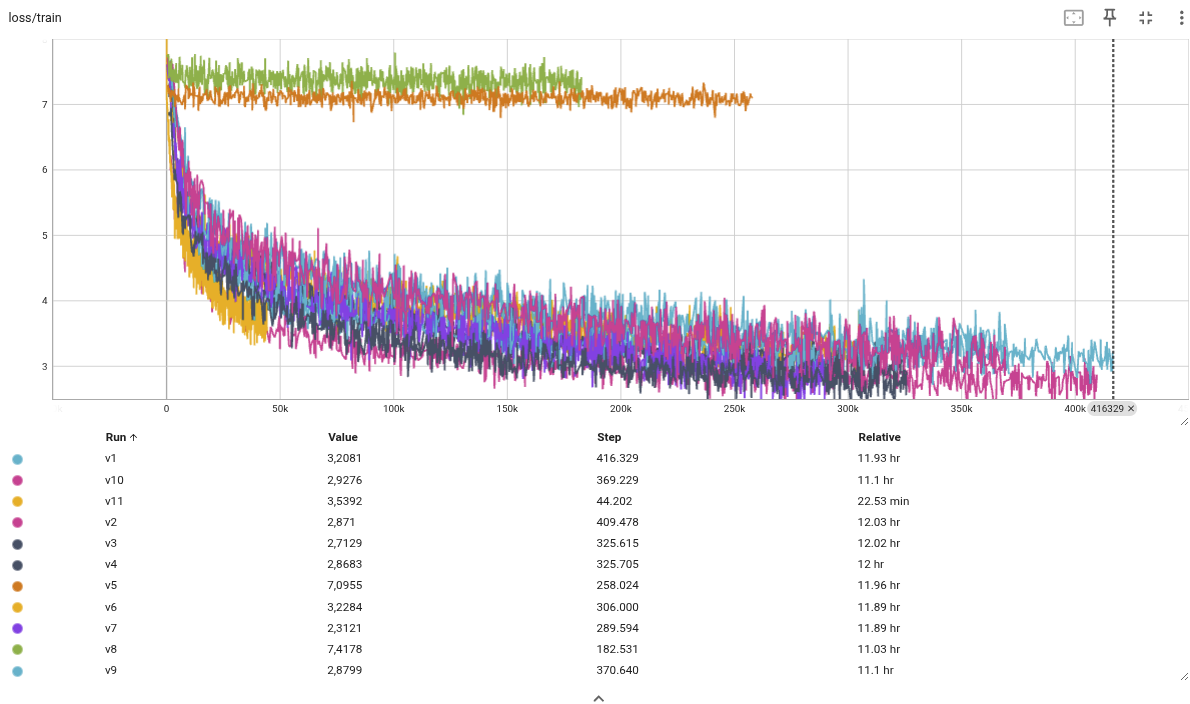
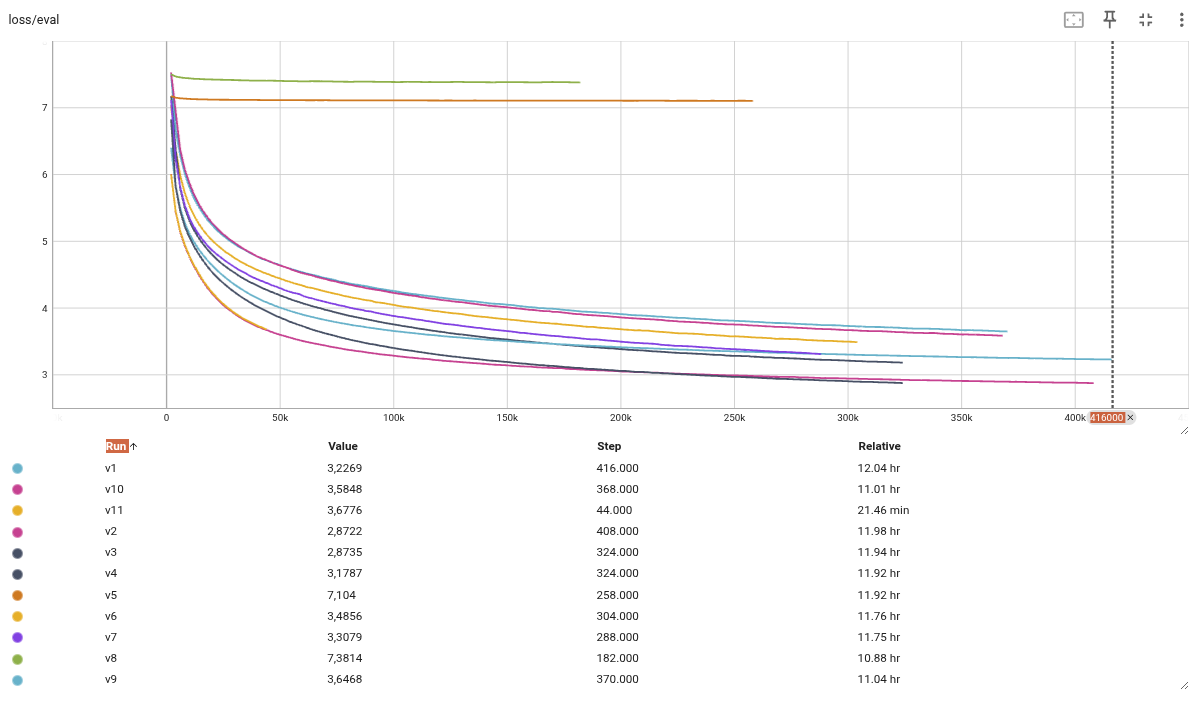

## 📉 Insights sobre a Loss

### 1. Instabilidade no treinamento

As oscilações observadas na loss de treinamento estão relacionadas ao baixo valor efetivo de `batch_size × accumulation_steps`.  

Essa configuração foi adotada para viabilizar o treinamento simultâneo de múltiplas versões do modelo sob restrições computacionais.  

Como consequência, o gradiente apresenta maior variância, o que explica as flutuações mais intensas na curva de loss.

---

### 2. Não convergência em modelos maiores (v5 e v8)

Os modelos de maior capacidade (v5 e v8) não apresentaram convergência estável.

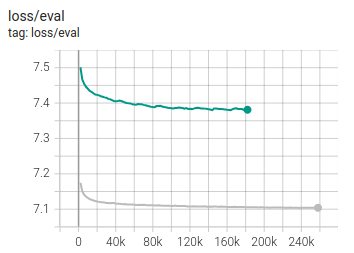

Em ambos os casos, observa-se divergência precoce, possivelmente causada por:

- Alta complexidade paramétrica para o regime de dados disponível  
- Escala inadequada de batch size para modelos maiores  
- Taxa de aprendizado não ajustada para a profundidade adicional  

---

### 3. Vocabulário 5k (v2 vs v3)

Os modelos com vocabulário de 5k tokens (v2 e v3), com diferença de duas camadas entre si, convergiram para valores próximos de loss de treinamento.

No entanto, analisando a loss de validação, observa-se que:

- A versão mais profunda (v3) demorou mais para estabilizar  
- Apresentava tendência de alcançar loss inferior caso o treinamento fosse prolongado  

Isso sugere que maior profundidade pode gerar melhor generalização, desde que haja tempo suficiente de otimização.

---

### 4. Vocabulário 10k (v4 vs v5)

Nos modelos com vocabulário de 10k tokens, a diferença de profundidade teve impacto mais significativo.

Enquanto a versão com menos camadas convergiu adequadamente, a versão mais profunda (v5, com 6 layers) não convergiu.

Isso pode indicar:

- Aumento excessivo da complexidade em relação ao volume de dados  
- Dificuldade de otimização em redes mais profundas nesse regime  
- Sensibilidade maior a hiperparâmetros
- Vanishing Gradients

---

### 5. Escala de embeddings e hidden size (v6 e v7)

Os modelos v6 e v7 exploraram aumento nas dimensões de embeddings e camadas ocultas:

- v6 → (256, 512)  
- v7 → (384, 768)  

Com vocabulário de 25k, ambos convergiram rapidamente e de forma estável.

Entretanto, observa-se tendência gradual de separação nas curvas de loss, sugerindo que, em um regime de treinamento mais longo, o modelo maior poderia obter vantagem mais significativa.

Isso indica que o aumento de dimensionalidade impacta positivamente a capacidade representacional.

---

### 6. Última tríade (v8, v9, v10)

A versão v8 apresentou comportamento semelhante ao v5, com não convergência precoce e perda de estabilidade em poucos steps.

Possíveis causas:

- Escala inadequada de batch size  
- Gradientes instáveis  
- Excesso de profundidade para o regime experimental  

Por outro lado, as versões restantes da tríade, com mesma quantidade de camadas porém diferentes dimensões internas, apresentaram convergência semelhante até aproximadamente 100k steps.

Após esse ponto, o modelo v10 — que possui maior discrepância entre dimensão de embedding e hidden size — começou a demonstrar vantagem progressiva.

Isso pode indicar que maior separação entre espaço de embedding e espaço oculto permite maior expressividade interna, favorecendo generalização em regimes mais longos de treinamento.


## 📈 Avaliação dos Gradientes

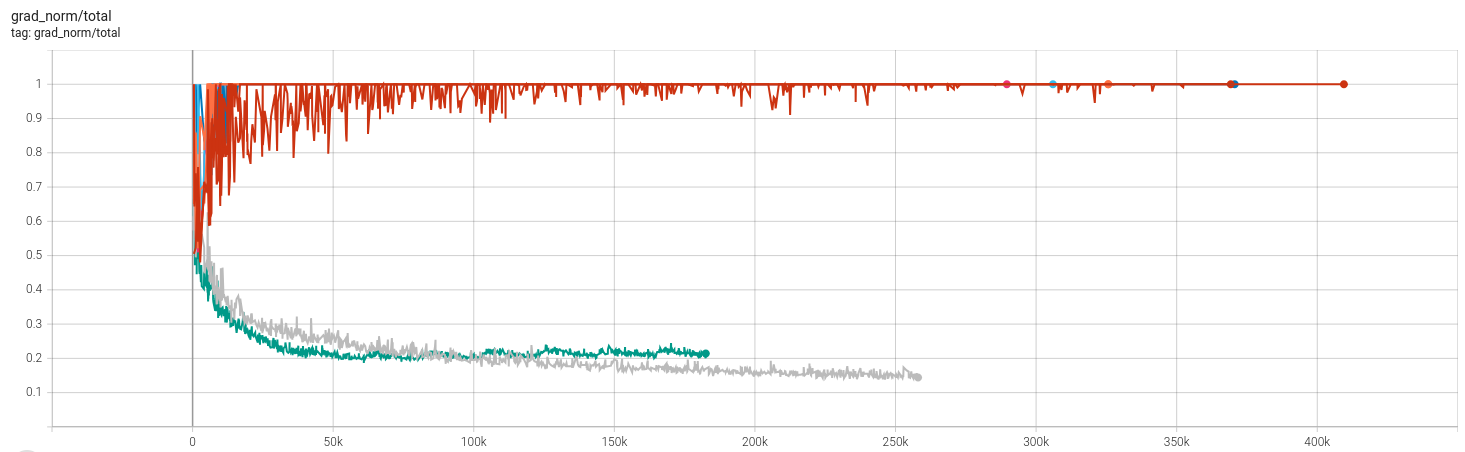

A análise das normas dos gradientes ao longo do treinamento permite compreender melhor os comportamentos observados nas curvas de loss.

---

### 1. Gradientes elevados nos modelos que convergiram

Observa-se que os modelos que efetivamente convergiram apresentaram picos elevados na norma dos gradientes ao longo do treinamento.

O modelo v3, em especial, apresentou os maiores valores de norma.

Importante destacar que:

- Gradientes elevados não necessariamente indicam instabilidade crítica.
- Em muitos casos, representam atualizações mais intensas no início do treinamento.
- Como houve convergência posterior, não se trata de exploding gradients destrutivo, mas sim de maior magnitude de atualização.

Isso sugere que o modelo v3 operou em regime de maior intensidade de aprendizado, possivelmente devido à maior profundidade.

---

### 2. Vanishing gradients nos modelos que não convergiram (v5 e v8)

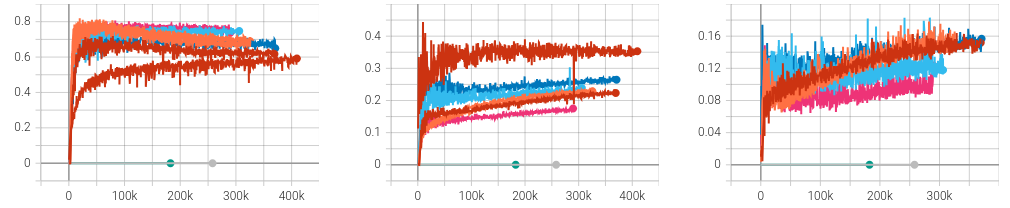

Nos modelos maiores que não convergiram (v5 e v8), observa-se comportamento oposto:

- As normas dos gradientes diminuem rapidamente.
- Em algumas camadas, os gradientes chegam próximos de zero.
- Especialmente nas primeiras camadas ocultas.

Esse comportamento é característico de **vanishing gradients**, indicando que o sinal de erro não estava sendo propagado adequadamente ao longo da rede.

Consequência direta:

- Camadas iniciais praticamente não aprendem.
- O modelo perde capacidade de ajuste.
- A otimização se torna ineficaz.

---

### 3. Desaparecimento progressivo do gradiente ao longo das camadas (v5)

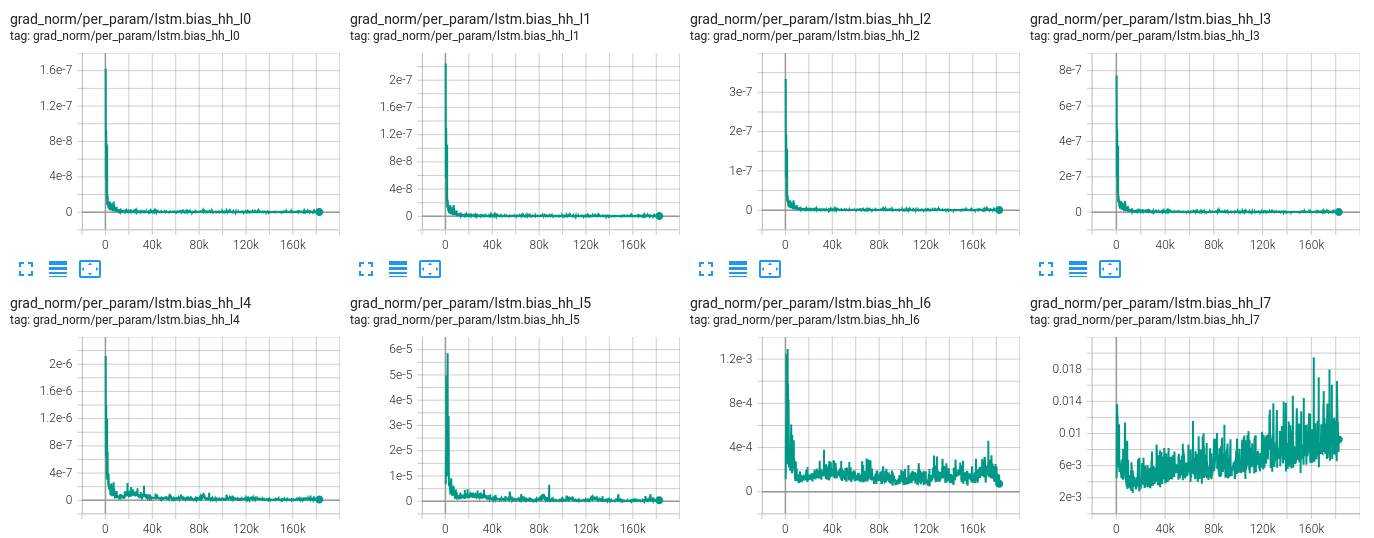

No modelo v5, observa-se claramente um padrão de decaimento da norma do gradiente conforme avançamos nas camadas ocultas.

Ou seja:

- Camadas mais profundas recebem gradientes mais fortes.
- Camadas iniciais recebem gradientes progressivamente menores.
- Em alguns casos, praticamente nulos.

Esse padrão confirma a hipótese de dificuldade na propagação do erro ao longo da profundidade da rede.

Possíveis causas:

- Profundidade excessiva para o regime de dados.
- Inicialização subótima.
- Escala inadequada do batch size.
- Taxa de aprendizado incompatível com a profundidade.
- Ausência de mecanismos adicionais de estabilização.

---

## 🧠 Interpretação Geral

A análise conjunta de loss e gradientes sugere que:

- Modelos moderadamente maiores conseguem suportar gradientes mais intensos e convergem.
- Modelos excessivamente grandes, para o regime experimental utilizado, entram em regime de vanishing gradients.
- O problema observado não foi explosão destrutiva, mas sim incapacidade de propagação do erro.

Isso reforça que aumentar profundidade ou dimensionalidade sem ajuste proporcional de hiperparâmetros e regime de treinamento pode comprometer a dinâmica de otimização.


In [9]:
config_test = {
    'batch_size': 64,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

step_info = {'test_accum_steps': 0, 'test_loss_sum':0}

In [10]:
df_test = pd.read_parquet('../data/test_wiki_cleaned_cutted.pq')

In [11]:
df_results = pd.DataFrame()
for model_name, item in modelos.items():
    modelo, tok = item

    modelo = modelo.to(config_test['device'])

    dataset_test = Dataset(
        df_test.text_cut.values.tolist(),
        tok,
        max_len=200
    )

    dataloader_test = torch.utils.data.DataLoader(
        dataset=dataset_test, 
        batch_size=config_test['batch_size'],
        shuffle=True
    )

    loss, phrases_pred, phrases_input, tokens_pred_total, tokens_input_total = test_step(config_test, step_info, modelo, dataloader_test, tok.get_vocab_size(), tok)
    df_results = pd.concat([df_results,pd.DataFrame({
        'modelo': [model_name]*len(phrases_input), 
        'frase_original': phrases_input, 
        'frase_preditada': phrases_pred,
        'tokens_originais': tokens_input_total,
        'tokens_preditados': tokens_pred_total,
        'loss': [loss]*len(phrases_input)
        })])

Testing: 100%|██████████| 2383/2383 [00:50<00:00, 47.20it/s]


In [ ]:
final_metrics, df_eval = evaluate_models(df_results)

## 📊 Explicação das Métricas — final_metrics

Abaixo tabela apresentará a comparação consolidada entre os modelos treinados.  
Cada linha representa um modelo diferente.

---

## 🏷️ `modelo`
Nome identificador do modelo avaliado.

---

## 📉 `loss`
Loss média no conjunto de teste.  
Quanto menor, melhor o ajuste probabilístico do modelo aos dados.

---

## 📏 Comprimento das Frases

### `len_original_words`
Número médio de palavras nas frases originais.

### `len_pred_words`
Número médio de palavras nas frases geradas pelo modelo.

### `len_original_tokens`
Número médio de tokens (tokenizador) nas frases originais.

### `len_pred_tokens`
Número médio de tokens nas frases preditas.

---

## 🔁 Razão de Comprimento

### `length_ratio_words`
Razão entre tamanho da frase predita e original (em palavras).

- ≈ 1 → modelo mantém tamanho semelhante  
- \> 1 → modelo tende a expandir  
- < 1 → modelo tende a encurtar  

### `length_ratio_tokens`
Mesma métrica acima, mas considerando tokens em vez de palavras.

---

## 🔄 Repetição (Degeneração)

### `token_repetition_rate`
Taxa média de repetição de tokens dentro da frase gerada.

Fórmula:

1 - (tokens únicos / total de tokens)

Interpretação:
- 0 → nenhum token repetido  
- próximo de 1 → alta repetição (colapso)

---

### `bigram_repetition`
Taxa média de repetição de bigramas (pares consecutivos).

Detecta padrões repetitivos estruturais curtos.

---

### `trigram_repetition`
Taxa média de repetição de trigramas.

Detecta degeneração estrutural mais longa.

---

## 🎯 Similaridade com a Frase Original (ROUGE)

### `rouge1`
Overlap de palavras individuais (unigram).

### `rouge2`
Overlap de bigramas.

### `rougeL`
Similaridade baseada na maior subsequência comum (Longest Common Subsequence).

Valores variam de 0 a 1:
- 1 → igual  
- 0 → completamente diferente  

---

## 🔗 `token_overlap`
Proporção de tokens preditos que também aparecem na frase original.

|tokens_orig ∩ tokens_pred| / |tokens_pred|

Indica o quanto o modelo reutiliza vocabulário do input.

---

## 🌍 `vocab_diversity`
Diversidade global do vocabulário usado pelo modelo.

tokens únicos gerados / total de tokens gerados

- Alto → modelo variado  
- Baixo → modelo colapsado  

---

## 📊 `corr_loss_repetition`
Correlação entre loss e repetição de tokens.

- Positiva → frases com maior loss tendem a repetir mais  
- Negativa → frases mais erradas repetem menos  
- Próxima de 0 → não há relação clara  

Ajuda a diagnosticar se degeneração está ligada ao erro do modelo.

---

# 🧠 Interpretação Geral

Um modelo saudável tende a apresentar:

- ✔️ Loss baixa  
- ✔️ ROUGE alto  
- ✔️ Repetição baixa  
- ✔️ Razão de comprimento próxima de 1  
- ✔️ Boa diversidade de vocabulário  


In [16]:
final_metrics

,modelo,loss,len_original_words,len_pred_words,len_original_tokens,len_pred_tokens,length_ratio_words,length_ratio_tokens,token_repetition_rate,bigram_repetition,trigram_repetition,rouge1,rouge2,rougeL,token_overlap,vocab_diversity,corr_loss_repetition
0,v10,3.583850,36.672659,36.952806,199.0,199.0,1.010171,1.0,0.858417,0.810962,0.804451,0.454467,0.225695,0.408506,0.499919,1.473095e-03,NaN
1,v11,2.868709,51.203290,194.293730,199.0,199.0,3.898648,1.0,0.762957,0.668318,0.631127,0.216175,0.096781,0.184799,0.476561,1.488650e-04,NaN
2,v2,2.872939,51.203290,51.685756,199.0,199.0,1.013163,1.0,0.796295,0.739732,0.733050,0.524620,0.248380,0.462263,0.551706,1.487991e-04,NaN
3,v3,2.873724,51.203290,51.038583,199.0,199.0,1.000772,1.0,0.796224,0.739858,0.733386,0.523190,0.249896,0.462763,0.551367,1.455364e-04,NaN
4,v4,3.180340,44.678856,49.327413,199.0,199.0,1.115213,1.0,0.818660,0.761509,0.751775,0.466803,0.213040,0.413277,0.507484,3.043873e-04,NaN
5,v5,7.103189,44.678856,38.000000,199.0,199.0,0.872674,1.0,0.974874,0.949495,0.918782,0.087166,0.003612,0.078858,0.702747,1.647831e-07,NaN
6,v6,3.485216,39.211914,62.197859,199.0,199.0,1.614554,1.0,0.841397,0.786028,0.775530,0.399375,0.182645,0.354534,0.476271,7.416556e-04,NaN
7,v7,3.310314,39.211914,39.551086,199.0,199.0,1.010806,1.0,0.844313,0.798657,0.793469,0.480442,0.244799,0.434600,0.515405,7.836753e-04,NaN
8,v8,7.382678,36.672659,31.000000,199.0,199.0,0.863469,1.0,0.974874,0.944444,0.928934,0.109653,0.004475,0.099173,0.699275,1.647831e-07,NaN
9,v9,3.642418,36.672659,37.569122,199.0,199.0,1.028856,1.0,0.860735,0.813620,0.807951,0.436414,0.207544,0.390252,0.493157,1.373269e-03,NaN


# 📊 Interpretação dos Resultados — `final_metrics`

A análise conjunta das métricas permite identificar padrões claros de comportamento entre os diferentes modelos.

---

## 🏆 Modelos com Melhor Equilíbrio Geral

### 🔹 v2 e v3 (Vocabulário 5k)

- Loss ≈ 2.87 (entre as menores)
- ROUGE1 ≈ 0.52 (maior entre todos os modelos)
- ROUGE2 ≈ 0.25
- ROUGE-L ≈ 0.46
- Razão de comprimento ≈ 1.0
- Repetição moderada (~0.79)

**Interpretação:**

Os modelos v2 e v3 apresentam o melhor equilíbrio entre:

- Ajuste probabilístico (loss baixa)
- Similaridade textual (ROUGE alto)
- Preservação do tamanho da frase
- Controle de repetição

Ambos se comportaram praticamente de forma idêntica, indicando que o aumento de duas camadas (v3) não trouxe ganho expressivo sob o regime atual de treinamento.

Esses modelos representam o melhor trade-off entre capacidade e estabilidade.

---

## 🥈 Modelo Estável com Maior Capacidade

### 🔹 v7

- Loss ≈ 3.31
- ROUGE1 ≈ 0.48
- Boa razão de comprimento (~1.01)
- Repetição levemente maior (~0.84)
- Maior diversidade de vocabulário dentre os modelos estáveis

**Interpretação:**

O v7 demonstra que o aumento de dimensionalidade (embedding + hidden size) mantém estabilidade e boa qualidade textual.

Apesar de ter loss maior que v2/v3, apresenta:

- Boa coerência estrutural
- Boa similaridade com o texto original
- Maior diversidade lexical

É um modelo com maior capacidade que ainda se mantém funcional.

---

## 📈 Modelos com Tendência à Expansão

### 🔹 v6 e v11

- v6 → razão de comprimento ≈ 1.61
- v11 → razão de comprimento ≈ 3.89 (!!)

**Interpretação:**

Esses modelos tendem a expandir excessivamente o texto em termos de palavras.

Especialmente o v11:

- Gera quase 4x mais palavras que o original
- ROUGE muito baixo (~0.21)
- Indica comportamento de geração descontrolada

Isso sugere dificuldade de modelar corretamente o encerramento ou a estrutura do texto.

---

## 🚨 Modelos que Colapsaram

### 🔴 v5 e v8

- Loss extremamente alta (>7)
- Repetição ~0.97 (quase total)
- ROUGE próximo de zero
- Diversidade lexical praticamente nula (~1e-7)
- Token overlap alto (~0.70)

**Interpretação:**

Esses modelos claramente colapsaram.

Características do colapso:

- Geração quase inteiramente repetitiva
- Vocabulário extremamente restrito
- Alto overlap porque repetem poucos tokens já presentes
- Não aprendem estrutura semântica

Esse padrão é consistente com o comportamento de vanishing gradients observado anteriormente.

---

## 📉 Modelos Intermediários

### 🔹 v4, v6, v9, v10

Apresentam:

- Loss intermediária (3.1 – 3.6)
- ROUGE moderado (0.39 – 0.46)
- Repetição elevada (~0.81 – 0.86)
- Diversidade lexical maior que v2/v3

**Interpretação:**

Esses modelos conseguem aprender parcialmente a estrutura do texto, mas:

- Sofrem com maior repetição
- Não atingem a qualidade textual dos mo


## Extra — Configuração de Geração de Texto

Para garantir uma comparação justa entre os modelos, utilizamos uma configuração determinística na geração:

- **Temperature = 1.0**  
  Mantém a distribuição original dos logits sem suavizar nem acentuar excessivamente as probabilidades.  
  Valores menores deixariam o modelo mais conservador; maiores, mais aleatório.

- **Top-k = 1**  
  Equivalente a *greedy decoding*.  
  A cada passo, o modelo escolhe apenas o token mais provável, eliminando aleatoriedade.

- **Sem exploração estocástica**  
  Como `k=1`, mesmo com temperatura aplicada, o processo se torna determinístico.

### Objetivo

Essa configuração foi escolhida para:

- Isolar a qualidade aprendida pelo modelo  
- Evitar que aleatoriedade influencie a comparação  
- Tornar os resultados reproduzíveis  

Assim, as diferenças observadas entre modelos refletem principalmente a capacidade de modelagem e não efeitos de amostragem.


In [21]:
initial_texts = [
    "São Paulo é um município",
    "O Brasil é um país",
    "A capital da França é",
    "A água é",
    "O Sol é",
    "A Terra gira em torno",
    "A fotossíntese é",
    "Um vírus é",
    "A energia elétrica é",
    "A linguagem humana é",
    "A democracia é",
    "O sistema solar é",
    "A Lua",
    "A Revolução Industrial",
    "A inteligência artificial é",
    "O aprendizado de máquina é",
    "A economia brasileira é",
    "O clima da Amazônia é",
    "A gravidade é",
    "A matemática é",
    "A música é",
    "A internet é",
    "O cérebro humano é",
    "A evolução das espécies é",
    "A ciência de dados é",
    "Um buraco negro é",
    "A energia nuclear é",
    "O capitalismo é",
    "O socialismo é",
    "A história do Brasil é"
]

In [33]:
def gerar_dataframe_predicoes(initial_texts, modelos, configs, k=1):
    
    registros = []
    
    for model_name, (model, tokenizer) in modelos.items():
        
        print(f"Gerando textos para {model_name}...")
        
        max_len = configs[model_name]['max_len']
        
        for prompt in initial_texts:
            
            try:
                texto_gerado = predicting(
                    prompt,
                    model.to('cpu'),
                    max_len,
                    tokenizer,
                    1,
                    1,
                    k=k
                )
                
                registros.append({
                    "modelo": model_name,
                    "prompt": prompt,
                    "texto_gerado": texto_gerado
                })
                
            except Exception as e:
                print(f"Erro no modelo {model_name} com prompt '{prompt}': {e}")
    
    df_resultados = pd.DataFrame(registros)
    
    return df_resultados

df_extra_prompts = gerar_dataframe_predicoes(initial_texts, modelos, configs)

Gerando textos para v2...
Gerando textos para v3...
Gerando textos para v4...
Gerando textos para v5...
Gerando textos para v6...
Gerando textos para v7...
Gerando textos para v8...
Gerando textos para v9...
Gerando textos para v10...
Gerando textos para v11...


In [38]:
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
df_extra_prompts.sample(50).sort_values('modelo')

,modelo,prompt,texto_gerado
255,v10,O aprendizado de máquina é,"O aprendizado de máquina é por um conjunto de técnicas , que podem ser utilizados para o público , ou seja , de acordo com a lei , o que faz com que o problema fosse a se afastar"
240,v10,São Paulo é um município,"São Paulo é um município localizado no estado de Santa Catarina , no Brasil Localiza - se a uma latitude sul e a uma longitude oeste , estando a uma altitude de 360 metros"
296,v11,A energia nuclear é,"A energia nuclear éa em inglês : ADN , em inglês : sigla , é uma função orgânica que é uma função orgânica que é o processo de doutrina que se liga a uma célula"
284,v11,A inteligência artificial é,"A inteligência artificial éa - se que a empresa é responsável pela operação de transporte de energia elétrica e de fixação de energia elétrica , que sejam adequados para a produção de energia"
272,v11,A capital da França é,"A capital da França éantes , que foi fundada em 1230 , quando o território de França , a França , a França , a França , a França , a França , a França , a França , a França , a França e a França"
298,v11,O socialismo é,"O socialismo éa , em especial , com o objetivo de preparar o pensamento e a cultura da sociedade , e a sua influência em um país , a fim de se tornar um movimento político"
7,v2,Um vírus é,"Um vírus é , um conjunto de vitaminas , ou seja , um ponto de vista de um ponto de vista , é um exemplo de uma função de um indivíduo ou grupo de pessoas"
23,v2,A evolução das espécies é,"A evolução das espécies é a um conjunto de plantas que sejam lendários , plantas , florestais , rios , rios , cadáculos , cadeias , costas , cadeias , costas , costeiras , costeiras , costeiras e rios"
15,v2,O aprendizado de máquina é,"O aprendizado de máquina é , um grande número de pessoas , e , portanto , um dos mais importantes exemplos de memória , adaptada de um determinado grupo de pessoas"
28,v2,O socialismo é,"O socialismo é , que é o estudo da política , e o direito de exercer o direito de exercer o direito de que a pessoa se torna um membro do partido"


## Última observação
Mesmo gerando as palavras corretamente, todos os modelos acabaram não conseguindo aprender a ter coerência